# SINDy logistic with noise

Two types of noise:

1. Additive, add $\mathcal N(0, \sigma)$ to the dynamics and use ReLU in case some of the datapoints become negative

$$
\left\{\begin{align*}

z_i &= L(t_i; x_0) + \gamma_i \\
\gamma_i &\sim \mathcal N(0, \sigma_\gamma^2) \\
y_i &= \text{ReLU}(z_i-\varepsilon)

\end{align*}\right.
$$

2. Multiplicative, multiply by $\mathcal N(1, \sigma)$ 

$$
\left\{\begin{align*}

z_i &= L(t_i; x_0) + \eta_i \\
\eta_i &\sim \mathcal N(1, \sigma_\eta^2) \\
y_i &= \text{ReLU}(z_i-\varepsilon)

\end{align*}\right.
$$

Reuse the pipeline as done previously

In [1]:
# modules
from torch import nn
import torch 
import pysindy as ps
from sr3_modified import my_SR3 as SR3
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint
from scipy.integrate import quad
import matplotlib as mpl 
from typing import Tuple 
from numpy.typing import NDArray
from scipy.optimize import fsolve
from typing import Literal, Union


In [2]:
# define the model same as before
k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


In [3]:
# helper function for polynomial definition

def poly_sindy(x, deg: int, model: ps.SINDy):
    # evaluates a polynomial of degree deg with trained SINDy model's coefficient
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)


In [4]:
# UDE

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [8]:
# calculate the steady state as the non-zero root of the polynomial term:

steady_state = fsolve(lambda x: poly_real(x, k+1), 1)
print(steady_state)

[0.93154041]


In [9]:
T_MAX = 10.

def get_training_data(x0: int, get_dynamics = False) -> Union[Tuple[NDArray, NDArray], Tuple[NDArray, NDArray, NDArray, NDArray]]:
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-8, atol=1e-8, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    mask = np.where(np.abs(X-steady_state) <= 1e-4)
    T_steady = T[mask[0][0]]

    mask_time = np.where(T <= T_steady+4)
    X_sliced = X[mask_time]
    T_sliced = T[mask_time]

    divider = len(X_sliced) // 10
    X_train = X_sliced[::divider+1]
    T_train = T_sliced[::divider+1]

    if not get_dynamics:
        return (X_train, T_train)
    else:
        return (X_train, T_train, sol.y.T.reshape(-1), sol.t)


In [10]:
def noise_data(data: NDArray, type: Literal['additive', 'multiplicative'], rng: np.random.Generator, mu: float, sigma: float, eps:float = 1e-4) -> NDArray:
    noise = rng.normal(mu, sigma, data.shape)

    return np.clip(data + noise - eps, 0, None) if type=='additive' else np.clip(data * noise - eps, 0, None)

Print two examples of noised data

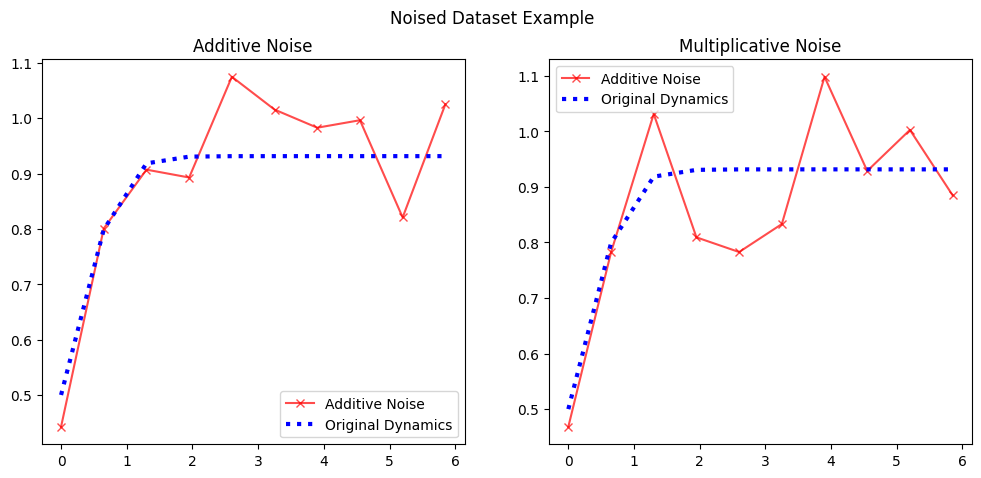

In [ ]:
rng = np.random.default_rng(67)

x0 = 0.5

sol, t_sol = get_training_data(x0, get_dynamics=False) # type: ignore

additive = noise_data(sol, 'additive', rng, 0, 0.1)
multiplicative = noise_data(sol, 'multiplicative', rng, 1, 0.1)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axes[0]
ax0.set_title("Additive Noise")
ax0.plot(t_sol, additive, label="Additive Noise", marker='x', alpha=0.7, color='red')
ax0.plot(t_sol, sol, linestyle=":", linewidth=3, label="Original Dynamics", color='blue')

ax0.legend()

ax1 = axes[1]
ax1.set_title("Multiplicative Noise")
ax1.plot(t_sol, multiplicative, label="Additive Noise", marker='x', alpha=0.7, color='red')

ax1.plot(t_sol, sol, linestyle=":", linewidth=3, label="Original Dynamics", color='blue')

ax1.legend()


plt.suptitle("Noised Dataset Example")
plt.show()


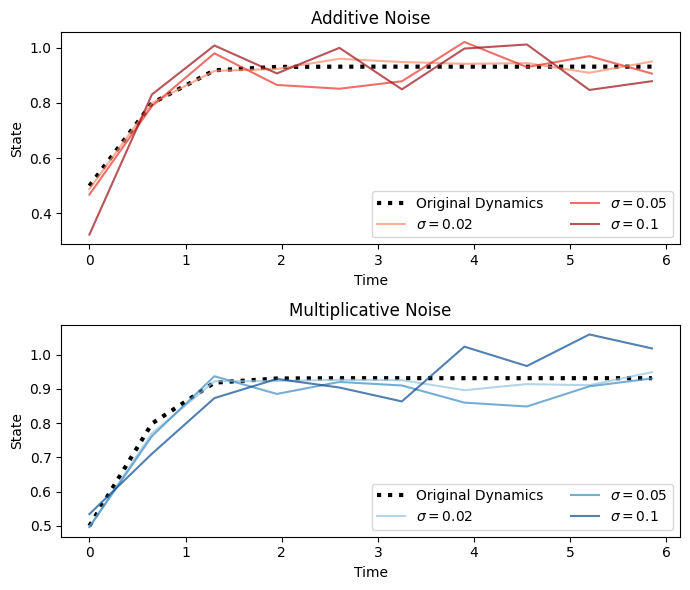

In [52]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(67)

x0 = 0.5
sol, t_sol = get_training_data(x0, get_dynamics=False)  # type: ignore
# Original dynamics
# Different sigma values
sigmas = [0.02, 0.05, 0.1]

# Colormaps
additive_colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(sigmas)))
multiplicative_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(sigmas)))

fig, axes = plt.subplots(2,1, figsize=(7, 6))

ax0 = axes[0]
ax1 = axes[1]
ax0.set_title("Additive Noise")
ax1.plot(
    t_sol,
    sol,
    linestyle=":",
    linewidth=3,
    color='black',
    label="Original Dynamics"
)
ax0.plot(
    t_sol,
    sol,
    linestyle=":",
    linewidth=3,
    color='black',
    label="Original Dynamics"
)

for sigma, color in zip(sigmas, additive_colors):
    additive = noise_data(sol, 'additive', rng, 0, sigma)

    ax0.plot(
        t_sol,
        additive,
        linestyle='-',
        alpha=0.7,
        color=color,
        label=fr'$\sigma={sigma}$'
    )

ax0.legend(ncol=2)
ax0.set_xlabel("Time")
ax0.set_ylabel("State")
ax1.set_title("Multiplicative Noise")

for sigma, color in zip(sigmas, multiplicative_colors):
    multiplicative = noise_data(sol, 'multiplicative', rng, 1, sigma)

    ax1.plot(
        t_sol,
        multiplicative,
        linestyle='-',
        alpha=0.7,
        color=color,
        label=fr'$\sigma={sigma}$'
    )


ax1.legend(ncol=2)
ax1.set_xlabel("Time")
ax1.set_ylabel("State")

plt.tight_layout()
plt.show()

Define full training pipeline and run

In [125]:

def train_model(x0: int, model: ude_generalised_growth, X_train: NDArray, T_train: NDArray) -> float:
    lr = 0.005
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_epochs = 2500

    t_train_torch = torch.tensor(T_train, dtype=torch.float32)
    x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
    x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

    for EPOCH in (range(n_epochs)):
        optimizer.zero_grad()
        
        # forward solution
        x_pred = odeint(model, 
                        x0_torch,
                        t_train_torch,
                        rtol=1e-7, atol=1e-7,
                        method='rk4'
                        )
        
        # Compute loss at training points

        loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
        
        # Backpropagate
        loss.backward()
        optimizer.step()
        
    return loss.item() # return the last loss


In [126]:
def train_sindy_models(x0, X_train: NDArray, T_train: NDArray, model: ude_generalised_growth) -> Tuple[ps.SINDy, ps.SINDy, ps.SINDy]:

    # baseline: numerically approximated derivates and origianl data
    baseline_model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000, verbose=False)
    )
    baseline_model.fit(X_train.reshape(-1, 1), T_train, feature_names=['x'])

    X_dot = torch.zeros(T_train.shape[0])

    for i, (t, x) in enumerate(zip(T_train, X_train)):
        X_dot[i] = model(t, torch.tensor([x], dtype=torch.float32))

    # ude1: UDE-enhanced approach, original data
    ude_model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=False)
    )

    ude_model.fit(X_train.reshape(-1, 1), T_train, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))

    # ude2: UDE-enhanced approach, more data!
    # recover data
    T_extended = torch.arange(0, np.max(T_train)+1, 0.05)


    sol = odeint(model, 
                        torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                        T_extended,
                        )

    data_new = sol.detach().numpy()

    T_extended_np = T_extended.detach().numpy().reshape(-1, 1)
    X_new = data_new.reshape(-1, 1)

    X_dot_new = torch.zeros(T_extended_np.shape[0])

    # train sindy model
    for i, (t, x) in enumerate(zip(T_extended_np, X_new)):
        X_dot_new[i] = model(t, torch.tensor([x], dtype=torch.float32))


    ude_model_augmented = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=False),
    )
    ude_model_augmented.fit(X_new, T_extended_np, feature_names=['x'], x_dot=X_dot_new.detach().numpy().reshape(-1, 1))

    return (baseline_model, ude_model, ude_model_augmented)

In [127]:
def results_sindy_models(baseline: ps.SINDy, ude1: ps.SINDy, ude2: ps.SINDy):
    # calculate L2 losses for each sindy model with respect to the real polynomial
    return {
        'baseline': quad(lambda x: ((poly_sindy(x, k+1, baseline)-poly_real(x, k+1))**2), 0, 1 )[0],
        'ude_enhanced': quad(lambda x: ((poly_sindy(x, k+1, ude1)-poly_real(x, k+1))**2), 0, 1 )[0],
        'ude_enhanced_augmented': quad(lambda x: ((poly_sindy(x, k+1, ude2)-poly_real(x, k+1))**2), 0, 1 )[0],
    }

In [139]:
# Case 1: Additive Noise

sigma_space = np.array([0, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5])

loss_models = []

l2_baseline = []
l2_ude = []
l2_superude = []

from tqdm import tqdm

x0 = 0.5
for sigma in tqdm(sigma_space):
    X_train, T_train = get_training_data(x0)

    rng = np.random.default_rng(67)
    new_X_train = noise_data(X_train, 'additive', rng, 0, sigma)
    
    ude_model = ude_generalised_growth(rho0)
    lass_lost = train_model(x0, ude_model, new_X_train, T_train)
    sindy_baseline, sindy_ude, sindy_ude_extended = train_sindy_models(x0, new_X_train, T_train, ude_model)

    dicts = results_sindy_models(sindy_baseline, sindy_ude, sindy_ude_extended)

    loss_models += [lass_lost]

    l2_baseline += [dicts['baseline']]
    l2_ude += [dicts['ude_enhanced']]
    l2_superude += [dicts['ude_enhanced_augmented']]
    

 29%|██▊       | 2/7 [01:46<04:30, 54.01s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 57%|█████▋    | 4/7 [03:22<02:29, 49.82s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 86%|████████▌ | 6/7 [04:53<00:47, 47.21s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 100000 iterations.
  warnings.warn(
100%|██████████| 7/7 [05:46<00:00, 49.46s/it]


In [153]:
np.savetxt("sindy_logs/loss_models_additive.txt", loss_models, delimiter="\t")
np.savetxt("sindy_logs/l2_baseline_additive.txt", l2_baseline, delimiter="\t")
np.savetxt("sindy_logs/l2_superude_additive.txt", l2_superude, delimiter="\t")
np.savetxt("sindy_logs/l2_ude_additive.txt", l2_ude, delimiter="\t")


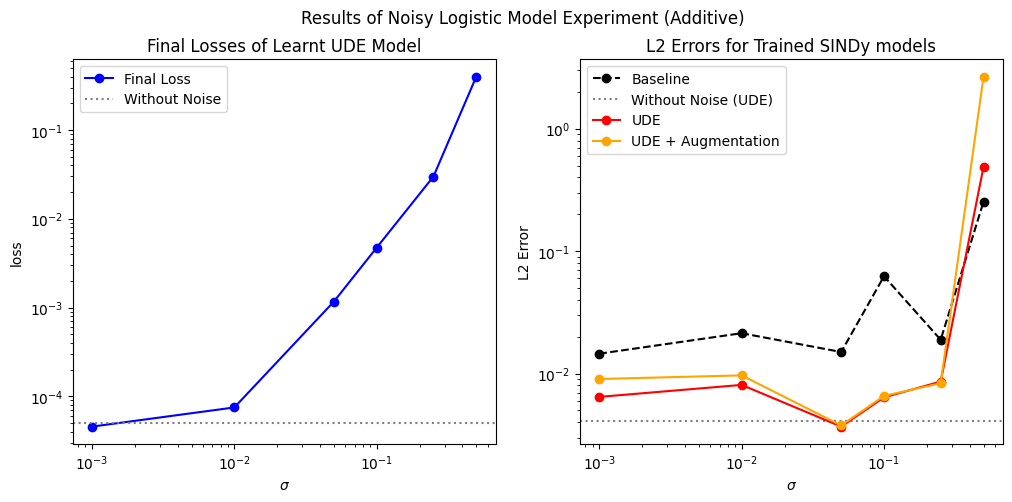

In [157]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axes[0]
ax1 = axes[1]

sigma_space = np.array([0, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5])

ax0.loglog(sigma_space[1:], loss_models[1:], color="blue", label="Final Loss", marker='o')
ax0.axhline(loss_models[0], color="grey", linestyle=":", label="Without Noise")
ax0.set_xlabel(r"$\sigma$")
ax0.set_ylabel("loss")

ax1.loglog(sigma_space[1:], l2_baseline[1:], label="Baseline", color="black", linestyle="--", marker='o')
ax1.axhline(l2_ude[0], color="grey", linestyle=":", label="Without Noise (UDE)")
ax1.loglog(sigma_space[1:], l2_ude[1:], label="UDE", color="red", marker='o')
ax1.loglog(sigma_space[1:], l2_superude[1:], label="UDE + Augmentation", color="orange", marker='o')
ax1.set_xlabel(r"$\sigma$")
ax1.set_ylabel("L2 Error")

ax1.set_title("L2 Errors for Trained SINDy models")
ax0.set_title("Final Losses of Learnt UDE Model")

ax0.legend()
ax1.legend()

plt.suptitle("Results of Noisy Logistic Model Experiment (Additive)")

plt.show()


In [158]:
# Case 1: Multiplicative Noise

sigma_space = np.array([0, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5])

loss_models = []

l2_baseline = []
l2_ude = []
l2_superude = []

from tqdm import tqdm

x0 = 0.5
for sigma in tqdm(sigma_space):
    X_train, T_train = get_training_data(x0)

    rng = np.random.default_rng(67)
    new_X_train = noise_data(X_train, 'multiplicative', rng, 1, sigma)
    
    ude_model = ude_generalised_growth(rho0)
    lass_lost = train_model(x0, ude_model, new_X_train, T_train)
    sindy_baseline, sindy_ude, sindy_ude_extended = train_sindy_models(x0, new_X_train, T_train, ude_model)

    dicts = results_sindy_models(sindy_baseline, sindy_ude, sindy_ude_extended)

    loss_models += [lass_lost]

    l2_baseline += [dicts['baseline']]
    l2_ude += [dicts['ude_enhanced']]
    l2_superude += [dicts['ude_enhanced_augmented']]
    

 29%|██▊       | 2/7 [01:30<03:44, 44.90s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 57%|█████▋    | 4/7 [02:57<02:12, 44.07s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
100%|██████████| 7/7 [05:06<00:00, 43.85s/it]


In [159]:
np.savetxt("sindy_logs/loss_models_multiplicative.txt", loss_models, delimiter="\t")
np.savetxt("sindy_logs/l2_baseline_multiplicative.txt", l2_baseline, delimiter="\t")
np.savetxt("sindy_logs/l2_superude_multiplicative.txt", l2_superude, delimiter="\t")
np.savetxt("sindy_logs/l2_ude_multiplicative.txt", l2_ude, delimiter="\t")


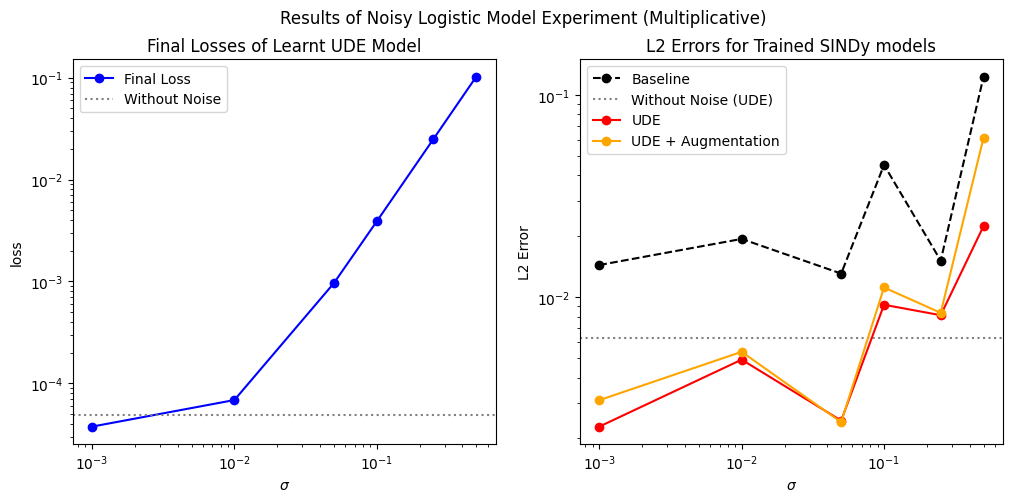

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axes[0]
ax1 = axes[1]

sigma_space = np.array([0, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5])

ax0.loglog(sigma_space[1:], loss_models[1:], color="blue", label="Final Loss", marker='o')
ax0.axhline(loss_models[0], color="grey", linestyle=":", label="Without Noise")
ax0.set_xlabel(r"$\sigma$")
ax0.set_ylabel("loss")

ax1.loglog(sigma_space[1:], l2_baseline[1:], label="Baseline", color="black", linestyle="--", marker='o')
ax1.axhline(l2_ude[0], color="grey", linestyle=":", label="Without Noise (UDE)")
ax1.loglog(sigma_space[1:], l2_ude[1:], label="UDE", color="red", marker='o')
ax1.loglog(sigma_space[1:], l2_superude[1:], label="UDE + Augmentation", color="orange", marker='o')
ax1.set_xlabel(r"$\sigma$")
ax1.set_ylabel("L2 Error")

ax1.set_title("L2 Errors for Trained SINDy models")
ax0.set_title("Final Losses of Learnt UDE Model")

ax0.legend()
ax1.legend()

plt.suptitle("Results of Noisy Logistic Model Experiment (Multiplicative)")

plt.show()
 